
# Theory

The **median filter** is a non-linear digital filtering technique, often used to remove noise from images or signals. It works by moving a window (usually $3 \times 3$) over each pixel in the image, replacing the center pixel with the median value of all the pixels within the window. Unlike linear filters, the median filter preserves edges while effectively reducing impulsive or "salt-and-pepper" noise.


Given an input image $I$ and a window $W$ of size $m \times n$, the median filter output $I'(x, y)$ at position $(x, y)$ is defined as:
$$
I'(x, y) = \text{median} \left\{ I(i, j) \mid (i, j) \in W_{x, y} \right\}
$$
where $W_{x, y}$ is the set of coordinates covered by the window centered at $(x, y)$.



In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def median_filter(input_image):
  img = input_image.resize((400,400), Image.Resampling.LANCZOS)

  fig = plt.figure()
  fig.set_figheight(20)
  fig.set_figwidth(20)

  #plotting original image
  fig.add_subplot(1,2,1)
  plt.imshow(img, cmap='gray')
  plt.title('original')


  # convert to numpy array 
  numpy_image = np.array(img)
  # array for padding
  array_b = np.zeros((402,402))

  # to pad initial array with zeros in all side
  array_b[1:401,1:401] = numpy_image

  #defining filter
  #filter_array = np.array([[1,1,1],
   #                        [1,1,1],
    #                       [1,1,1]])
  
  filter_array = np.array([[3,3,3],
                           [3,3,3],
                           [3,3,3]])
  
  #creating empty list
  lst = []

  for i in range(400):
    for j in range(400):
      #extracting part of array equal to filter size
      array_c = array_b[i:(3+i),j:(3+j)]
    
     #applying filter
      array_mul = np.multiply(filter_array,array_c)
      array_sum = np.median(array_mul)
    
      # putting calculated value in list
      lst.append(array_sum)

  # resizing lst to shape of original array
  final_array = np.resize(lst,(400,400))

  final_image = Image.fromarray(final_array)
  final_image= final_image.convert("L")

    #plotting filtered image
  fig.add_subplot(1,2,2)
  plt.imshow(final_image, cmap='gray')
  plt.title('filtered image')
  

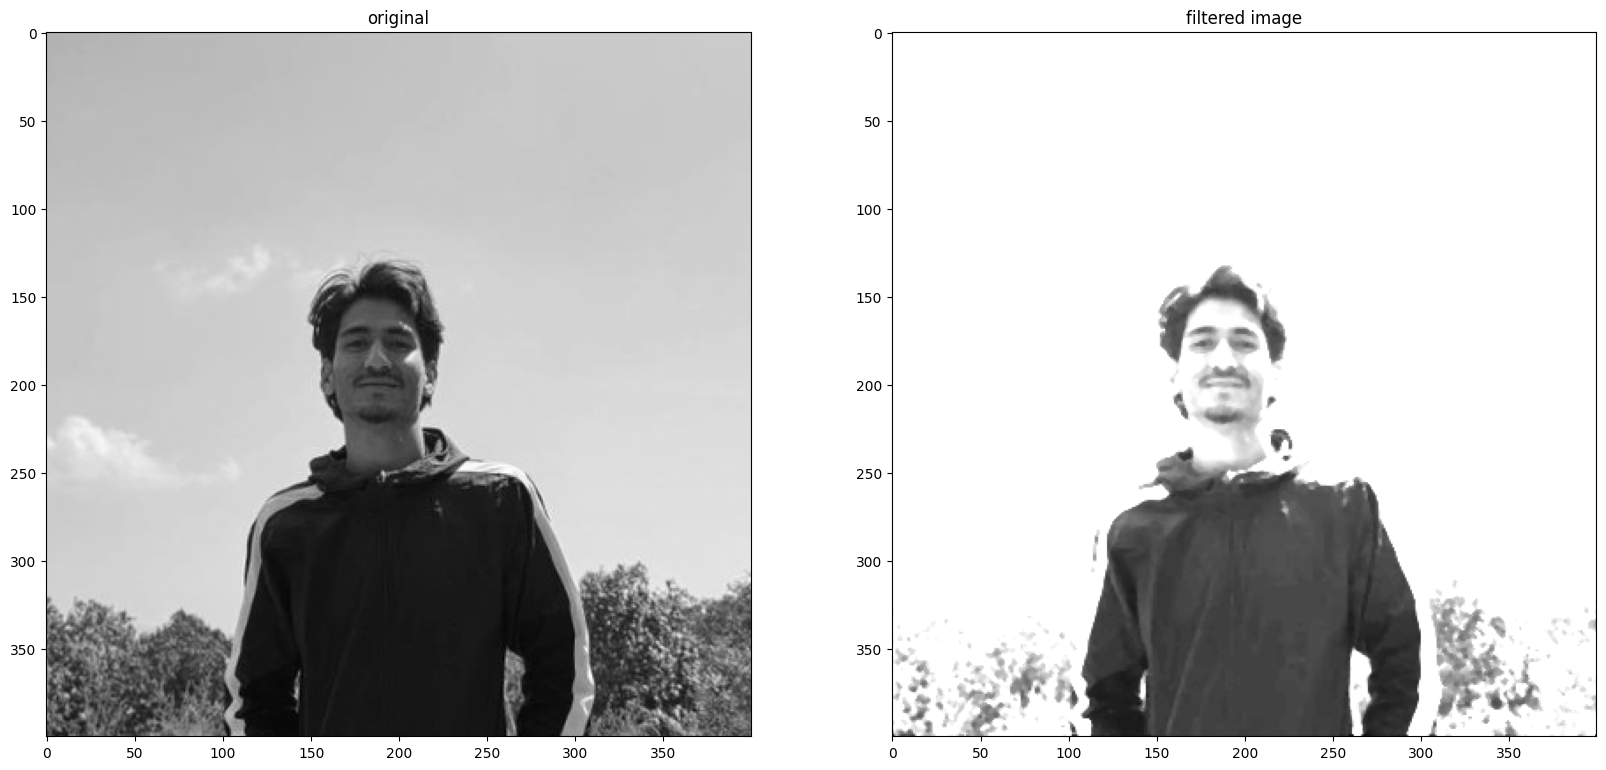

: 

In [ ]:
# reading image and converting to gray scale
img = Image.open('img/prakash.jpg').convert('L')
# Call filter function
median_filter(img)


# Conclusion

The median filter is highly effective for removing impulsive noise while preserving important image features such as edges. In this lab, the filter was applied to a grayscale image, demonstrating significant noise reduction without blurring the image. This makes the median filter a preferred choice for preprocessing in many image processing applications.